## Sentiment Analysis on Product Review

#### Step 1 -  Dataset
Use the Amazon Product Reviews dataset from Kaggle. It has reviewText and overall (1–5 stars) columns.

#### Step 2 - Label the Sentiments
Convert star ratings:
````
4–5 ⭐ → Positive
3 ⭐ → Neutral
1–2 ⭐ → Negative
````

#### Step 3 - Text Preprocessing
- Lowercase all text
- Remove punctuation, numbers, special chars
- Remove stopwords (the, is, at...)
- Apply Stemming or Lemmatization

#### Step 4 - Feature Extraction
Use TF-IDF Vectorizer (converts text → numbers the model understands)

#### Step 5 - Train/Test Split
Split data → 80% train, 20% test

#### Step 6 - Train the Model
Train Logistic Regression and SVM, compare results

#### Step 7 - Evaluate
Use Accuracy, Precision, Recall, F1-Score, Confusion Matrix


## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import re
import nltk

In [3]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)

In [5]:
# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\Purvi
[nltk_data]     jain\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Purvi
[nltk_data]     jain\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Load Dataset

In [9]:
df = pd.read_csv("../00_Datasets/Customer_Sentiment.csv")

In [10]:
df.shape

(25000, 13)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customer_id           25000 non-null  int64 
 1   gender                25000 non-null  object
 2   age_group             25000 non-null  object
 3   region                25000 non-null  object
 4   product_category      25000 non-null  object
 5   purchase_channel      25000 non-null  object
 6   platform              25000 non-null  object
 7   customer_rating       25000 non-null  int64 
 8   review_text           25000 non-null  object
 9   sentiment             25000 non-null  object
 10  response_time_hours   25000 non-null  int64 
 11  issue_resolved        25000 non-null  object
 12  complaint_registered  25000 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.5+ MB


In [13]:
df.isnull().sum()

customer_id             0
gender                  0
age_group               0
region                  0
product_category        0
purchase_channel        0
platform                0
customer_rating         0
review_text             0
sentiment               0
response_time_hours     0
issue_resolved          0
complaint_registered    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.head()

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
0,1,male,60+,north,automobile,online,flipkart,1,very disappointed with the quality.,negative,46,yes,yes
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no
2,3,female,36-45,east,sports,online,facebook marketplace,1,very disappointed with the quality.,negative,38,yes,yes
3,4,female,18-25,central,groceries,online,zepto,2,product stopped working after few days.,negative,16,yes,yes
4,5,female,18-25,east,electronics,online,croma,3,neutral about the quality.,neutral,15,yes,no


C:\Users\Purvi jain\AppData\Local\Temp\ipykernel_19760\2425247948.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='Set2')


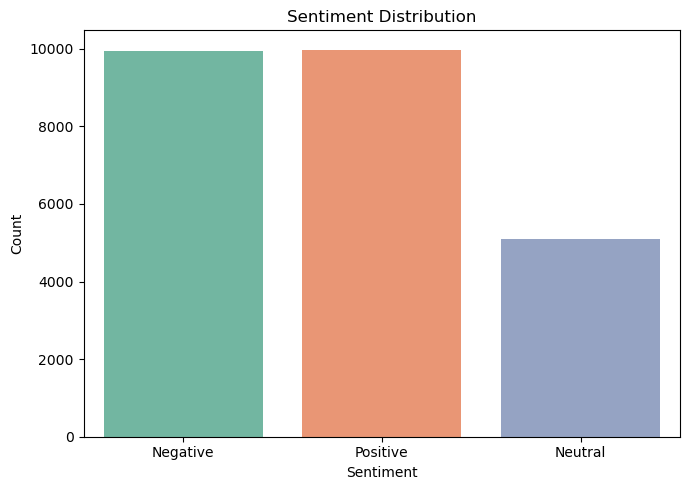

In [20]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='sentiment', palette='Set2')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

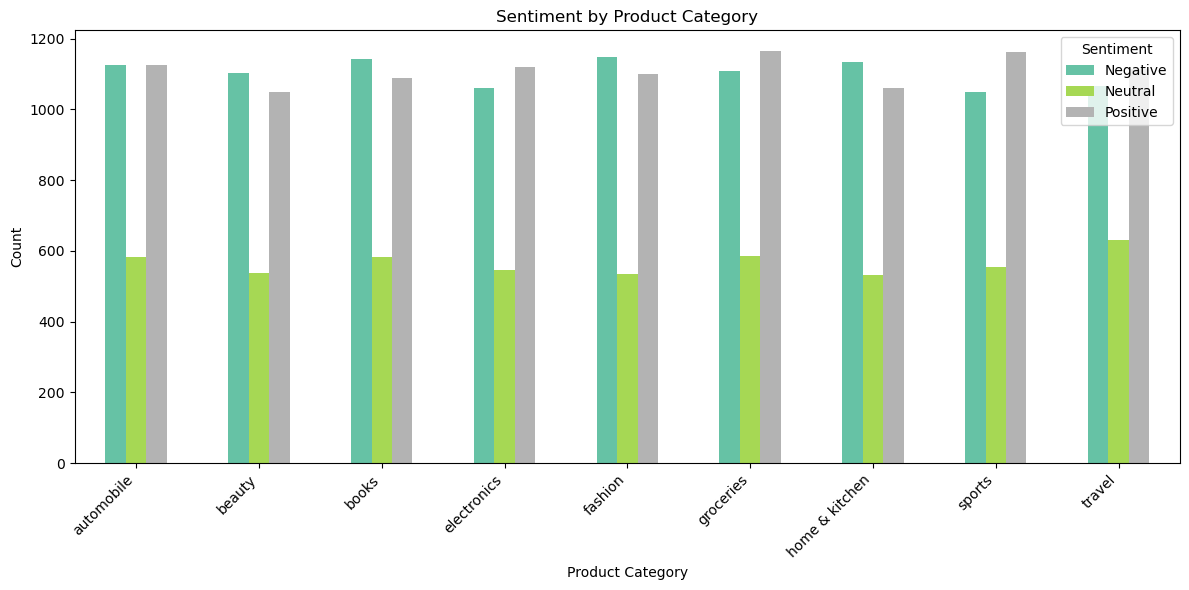

In [21]:
plt.figure(figsize=(12, 6))
category_sentiment = df.groupby(['product_category', 'sentiment']).size().unstack(fill_value=0)
category_sentiment.plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title('Sentiment by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

C:\Users\Purvi jain\AppData\Local\Temp\ipykernel_19760\3283307428.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y='review_length', palette='Set2')


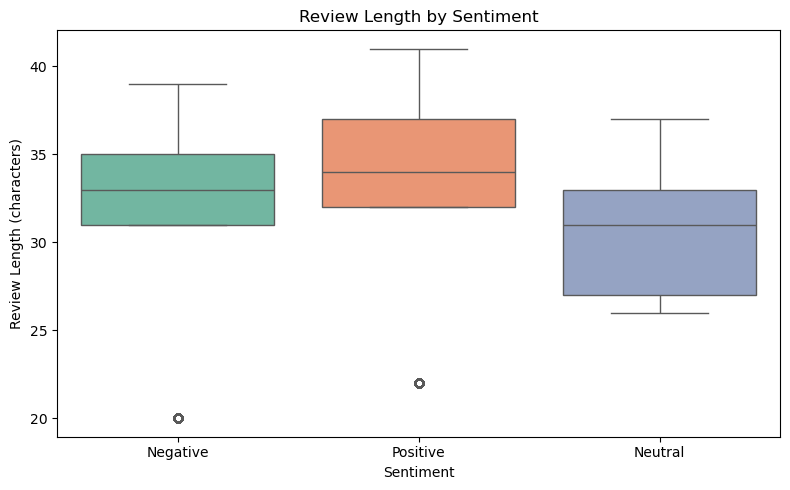

In [22]:
df['review_length'] = df['review_text'].str.len()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='sentiment', y='review_length', palette='Set2')
plt.title('Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Review Length (characters)')
plt.tight_layout()
plt.show()

## Label of Reviews

In [23]:
def label_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['customer_rating'].apply(label_sentiment)
print(df['sentiment'].value_counts())

sentiment
Positive    9978
Negative    9937
Neutral     5085
Name: count, dtype: int64


## Text Preprocessing

In [24]:
stem = PorterStemmer()
stop_words = set(stopwords.words('english'))

In [25]:
# This function cleans raw text by removing special characters, converting to lowercase, removing stopwords, applying stemming, and returning a normalized sentence for NLP modeling.

def preprocess(text):
    text = re.sub(r'[^a-z\s]', ' ', str(text))
    text = text.lower()
    text = text.split()
    text = [stem.stem(w)
            for w in text
            if w not in stop_words]   
    
    return ' '.join(text)

In [26]:
df['clean_review'] = df['review_text'].apply(preprocess)
print(df[['review_text', 'clean_review']].head())

                               review_text                clean_review
0      very disappointed with the quality.          disappoint qualiti
1       fast delivery and great packaging.  fast deliveri great packag
2      very disappointed with the quality.          disappoint qualiti
3  product stopped working after few days.       product stop work day
4               neutral about the quality.             neutral qualiti


## TF-IDF Feature Extraction

In [27]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

x = tfidf.fit_transform(df['clean_review'])   # input feature
y = df['sentiment']   # output label

## Train-Test Split

In [28]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

## Train the Model

In [29]:
# Logistic Regression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(x_train, y_train)
lr_predict = lr_model.predict(x_test)

In [30]:
# SVM

svm_model = LinearSVC()
svm_model.fit(x_train, y_train)
svm_predict = svm_model.predict(x_test)

In [31]:
print(lr_model.classes_)

['Negative' 'Neutral' 'Positive']


## Evaluate the Models

In [32]:
print("\n ------ Logistic Regression ------")
print("Accuracy: ", accuracy_score(y_test, lr_predict)) # Calculates the overall accuracy of the model
print(classification_report(y_test, lr_predict)) # Gives a detailed performance summary


 ------ Logistic Regression ------
Accuracy:  1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1987
     Neutral       1.00      1.00      1.00      1017
    Positive       1.00      1.00      1.00      1996

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



In [33]:
print("\n ------ SVM ------")
print("Accuracy: ", accuracy_score(y_test, svm_predict)) # Calculates the overall accuracy of the model
print(classification_report(y_test, svm_predict)) # Gives a detailed performance summary


 ------ SVM ------
Accuracy:  1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1987
     Neutral       1.00      1.00      1.00      1017
    Positive       1.00      1.00      1.00      1996

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



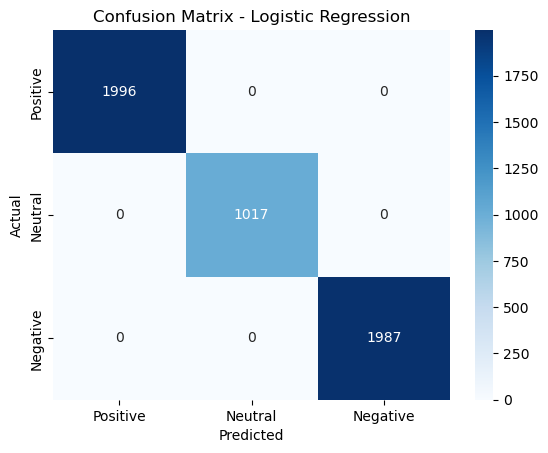

In [34]:
# Confusion Matrix
cm = confusion_matrix(y_test, lr_predict, labels=['Positive','Neutral','Negative'])
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Positive','Neutral','Negative'],
            yticklabels=['Positive','Neutral','Negative'],
            cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## Testing the model : Predict on new review

In [35]:
def predict_sentiment(review_text):
    cleaned = preprocess(review_text)
    vectorized = tfidf.transform([cleaned])
    prediction = lr_model.predict(vectorized)
    return prediction[0]

#### Test it!

In [36]:
test_review = "The product quality is excellent and I really love it."
print(f"\nReview: {test_review}")
print(f"Predicted Sentiment: {predict_sentiment(test_review)}")


Review: The product quality is excellent and I really love it.
Predicted Sentiment: Positive


In [37]:
test_review = "The product is very poor and stopped working after one day."
print(f"\nReview: {test_review}")
print(f"Predicted Sentiment: {predict_sentiment(test_review)}")


Review: The product is very poor and stopped working after one day.
Predicted Sentiment: Negative


In [38]:
test_review = "The product is okay, it works as expected."
print(f"\nReview: {test_review}")
print(f"Predicted Sentiment: {predict_sentiment(test_review)}")


Review: The product is okay, it works as expected.
Predicted Sentiment: Neutral
